# Load Libs

In [1]:
pip install --upgrade onnx onnxscript


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.3/159.3 kB 8.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import os 
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import onnx

# Shaping tha Dataset

In [3]:
class ShapesDataset(Dataset):

    
    def __init__(self, csv_file, img_dir, transform=None):
        self.labels_df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        self.class_folders = ['class0', 'class1', 'class2']
        self.class_names = ['Square', 'Triangle', 'Circle']
        
        print(f"csv shape: {self.labels_df.shape}")
        print(f"csv columns: {self.labels_df.columns.tolist()}")


    
    def __len__(self):
        return len(self.labels_df)



    
    def __getitem__(self, idx):
        img_name = str(self.labels_df.iloc[idx, 0])
        label = int(self.labels_df.iloc[idx, 1])
        
        folder_name = self.class_folders[label]
        img_path = os.path.join(self.img_dir, folder_name, img_name)
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Transform and import data 

In [4]:
from torchvision.datasets import ImageFolder



transform = transforms.Compose([transforms.Resize((32, 32)),
                                transforms.RandomHorizontalFlip(p=0.3),
                                transforms.RandomRotation(10),
                                transforms.ToTensor(),
                                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])




dataset = ImageFolder(root="/kaggle/input/datasets/carlodemello/shapes2/Shapes",  # so this points to the folder containing class0, class1, class2
                      transform=transform)




print(f"total images: {len(dataset)}")
print(f"classes: {dataset.classes}")
print(f"class to index: {dataset.class_to_idx}")

total images: 30001
classes: ['class0', 'class1', 'class2']
class to index: {'class0': 0, 'class1': 1, 'class2': 2}


# Labeling the data

In [5]:
from collections import Counter
labels = [label for _, label in dataset]


print(f"class distribution: {Counter(labels)}")

class distribution: Counter({2: 10001, 0: 10000, 1: 10000})


# Splitting data 

In [6]:
from torch.utils.data import random_split

train_size = 18002
test_size = len(dataset) - train_size   # here I used the ratio of 60 - 40, you can use 70 -30 or 80 -20, so a lot of r&d

if test_size < 0:
    test_size = 0
    train_size = len(dataset)

print(f"training Data: {train_size}")
print(f"test Data: {test_size}")

train_set, test_set = random_split(dataset, [train_size, test_size])

training Data: 18002
test Data: 11999


# giving batch size 

In [7]:
batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)




print(f"train batches: {len(train_loader)}")
print(f"test batches: {len(test_loader)}")





images, labels = next(iter(train_loader))       # so this shows you the sample
print(f"batch shape: {images.shape}")
print(f"labels: {labels[:5]}")

train batches: 282
test batches: 188
batch shape: torch.Size([64, 3, 32, 32])
labels: tensor([0, 0, 1, 2, 1])


# Loading CNN model

In [8]:
class ShapesCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(nn.Conv2d(3, 32, kernel_size=3, padding=1),
                           nn.BatchNorm2d(32),
                           nn.ReLU(),
                           nn.MaxPool2d(2),
            
                           nn.Conv2d(32, 64, kernel_size=3, padding=1),
                           nn.BatchNorm2d(64),
                           nn.ReLU(),
                           nn.MaxPool2d(2),
            
                           nn.Conv2d(64, 128, kernel_size=3, padding=1),
                           nn.BatchNorm2d(128),
                           nn.ReLU(),
                           nn.MaxPool2d(2))
        
        self.classifier = nn.Sequential(nn.Flatten(),
                          nn.Linear(128 * 4 * 4, 256),
                          nn.ReLU(),
                          nn.Dropout(0.5),
                          nn.Linear(256, 128),
                          nn.ReLU(),
                          nn.Dropout(0.3),
                          nn.Linear(128, 3))
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
                    
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.classifier(x)
        return x

# Setting CNN model 

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ShapesCNN().to(device)



learning_rate = 0.0005
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)



print(f"Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cpu
Model parameters: 651,523


# Assigning loader, model, loss function and optimizer

In [10]:
def train_epoch(loader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    train_acc = 100. * correct / total
    avg_loss = total_loss / len(loader)
    return avg_loss, train_acc

In [11]:
def validate_epoch(loader, model, loss_fn):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    
    val_acc = 100. * correct / total
    avg_loss = total_loss / len(loader)
    return avg_loss, val_acc

# starting model training with given epochs as per trial basis

In [12]:
epochs = 5
best_acc = 0
patience = 5
patience_counter = 0



train_losses = []
train_accs = []
val_losses = []
val_accs = []




for epoch in range(epochs):
    print(f'\nEpoch {epoch+1}/{epochs}')
    
    train_loss, train_acc = train_epoch(train_loader, model, loss_fn, optimizer)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    val_loss, val_acc = validate_epoch(test_loader, model, loss_fn)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f'train loss: {train_loss:.4f}, train acc: {train_acc:.2f}%')
    print(f'val loss: {val_loss:.4f}, val acc: {val_acc:.2f}%')
    
    scheduler.step(val_loss)



    
    if val_acc > best_acc:
        best_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'new best model saved: {val_acc:.2f}% ***')

    
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'  early stopping after {epoch+1} epochs')
            break


Epoch 1/5
train loss: 1.0017, train acc: 45.22%
val loss: 0.8253, val acc: 59.54%
new best model saved: 59.54% ***

Epoch 2/5
train loss: 0.7323, train acc: 64.94%
val loss: 0.6096, val acc: 71.03%
new best model saved: 71.03% ***

Epoch 3/5
train loss: 0.5396, train acc: 74.92%
val loss: 0.4370, val acc: 79.36%
new best model saved: 79.36% ***

Epoch 4/5
train loss: 0.4229, train acc: 79.88%
val loss: 0.3360, val acc: 84.60%
new best model saved: 84.60% ***

Epoch 5/5
train loss: 0.3610, train acc: 83.05%
val loss: 0.3186, val acc: 85.25%
new best model saved: 85.25% ***


In [13]:
model.load_state_dict(torch.load('best_model.pth', weights_only=True))
model.eval()

ShapesCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dro


final test accuracy: 85.19%


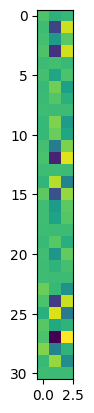

In [14]:
all_preds = []
all_labels = []
all_probs = []



with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        plt.imshow(outputs)
        import matplotlib.pyplot as plt
        probs = torch.nn.functional.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())


all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)



accuracy = np.mean(all_preds == all_labels) * 100
print(f"\nfinal test accuracy: {accuracy:.2f}%")

In [15]:
from keras.preprocessing import image
import numpy as np




2026-02-17 17:32:32.535290: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771349552.801272      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771349552.879299      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771349553.523199      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771349553.523241      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771349553.523244      17 computation_placer.cc:177] computation placer alr

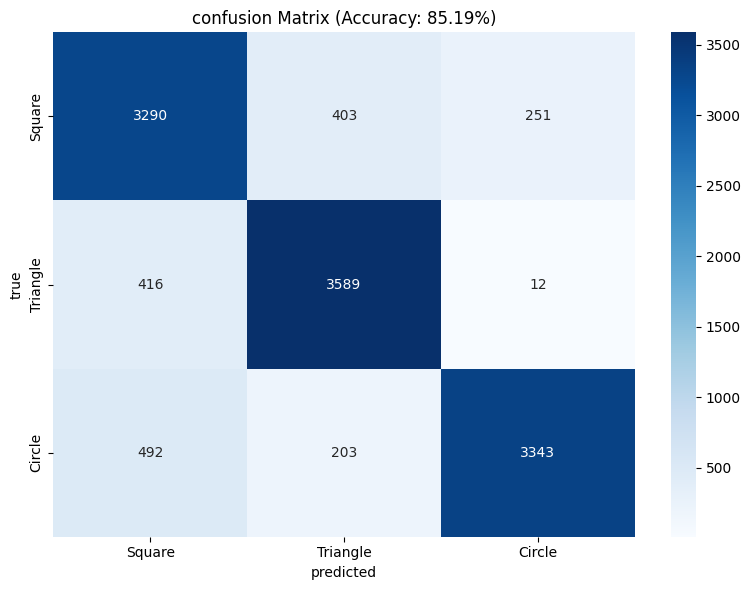

In [16]:
class_names = ['Square', 'Triangle', 'Circle']



cm = confusion_matrix(all_labels, all_preds)




plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)

plt.xlabel('predicted')
plt.ylabel('true')
plt.title(f'confusion Matrix (Accuracy: {accuracy:.2f}%)')
plt.tight_layout()
plt.show()

# Classification report 

In [17]:
print("\nclassification report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))


classification report:
              precision    recall  f1-score   support

      Square     0.7837    0.8342    0.8082      3944
    Triangle     0.8555    0.8935    0.8741      4017
      Circle     0.9271    0.8279    0.8747      4038

    accuracy                         0.8519     11999
   macro avg     0.8554    0.8518    0.8523     11999
weighted avg     0.8560    0.8519    0.8526     11999



In [18]:
correct_mask = all_preds == all_labels
correct_confidences = all_probs[correct_mask].max(axis=1)
wrong_confidences = all_probs[~correct_mask].max(axis=1)





print(f"\nconfidence analysis:")
print(f"correct predictions ({len(correct_confidences)} samples):")
print(f"  mean confidence: {correct_confidences.mean():.4f}")
print(f"  min confidence: {correct_confidences.min():.4f}")
print(f"  max confidence: {correct_confidences.max():.4f}")






if len(wrong_confidences) > 0:
    print(f"\nwrong predictions ({len(wrong_confidences)} samples):")
    print(f"  mean confidence: {wrong_confidences.mean():.4f}")
    print(f"  min confidence: {wrong_confidences.min():.4f}")
    print(f"  max confidence: {wrong_confidences.max():.4f}")


confidence analysis:
correct predictions (10222 samples):
  mean confidence: 0.8829
  min confidence: 0.3512
  max confidence: 1.0000

wrong predictions (1777 samples):
  mean confidence: 0.4820
  min confidence: 0.3506
  max confidence: 0.9987


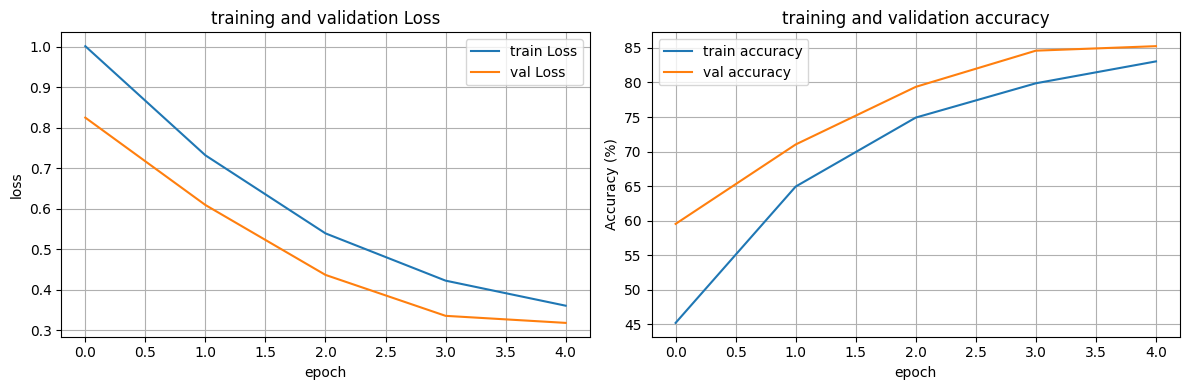

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train Loss')
plt.plot(val_losses, label='val Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('training and validation Loss')
plt.legend()
plt.grid(True)



plt.subplot(1, 2, 2)
plt.plot(train_accs, label='train accuracy')
plt.plot(val_accs, label='val accuracy')
plt.xlabel('epoch')
plt.ylabel('Accuracy (%)')
plt.title('training and validation accuracy')
plt.legend()
plt.grid(True)




plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

results_df = pd.DataFrame({'true_label': all_labels,
                           'predicted_label': all_preds,
                           'confidence': all_probs.max(axis=1),
                           'is_correct': all_preds == all_labels})


for i, class_name in enumerate(class_names):
    results_df[f'prob_{class_name}'] = all_probs[:, i]



results_df.to_csv('model_predictions.csv', index=False)
print(f"\ndetailed predictions saved to 'model_predictions.csv'")


detailed predictions saved to 'model_predictions.csv'


# load libs

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import os 
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time
from torchvision.datasets import ImageFolder

# transform and load data

In [22]:
transform = transforms.Compose([transforms.Resize((32, 32)),
                                transforms.ToTensor(),
                                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])



dataset = ImageFolder(root="/kaggle/input/datasets/carlodemello/shapes2/Shapes",
                      transform=transform)



print(f"total images: {len(dataset)}")
print(f"classes: {dataset.classes}")
print(f"class to index: {dataset.class_to_idx}")





train_size = 18002
test_size = len(dataset) - train_size




train_set, test_set = random_split(dataset, [train_size, test_size])




batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)




print(f"\ntrain batches: {len(train_loader)}")
print(f"test batches: {len(test_loader)}")

total images: 30001
classes: ['class0', 'class1', 'class2']
class to index: {'class0': 0, 'class1': 1, 'class2': 2}

train batches: 282
test batches: 188


In [23]:
conv_layers_data = {i: [] for i in range(1, 13)}


In [24]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(nn.Conv2d(3, 32, kernel_size=3, padding=1),
                                         nn.BatchNorm2d(32),
                                         nn.ReLU(),
                                         nn.MaxPool2d(2),
            
                                         nn.Conv2d(32, 64, kernel_size=3, padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(),
                                         nn.MaxPool2d(2),
            
                                         nn.Conv2d(64, 128, kernel_size=3, padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU(),
                                         nn.MaxPool2d(2),
            
                                         nn.Conv2d(128, 256, kernel_size=3, padding=1),
                                         nn.BatchNorm2d(256),
                                         nn.ReLU(),
                                         nn.MaxPool2d(2))

        
        
        self.classifier = nn.Sequential(nn.Flatten(),
                                        nn.Linear(256 * 2 * 2, 512),
                                        nn.ReLU(),
                                        nn.Dropout(0.5),
                                        nn.Linear(512, 256),
                                        nn.ReLU(),
                                        nn.Dropout(0.3),
                                        nn.Linear(256, 3))

    
        
    def forward(self, x):
        conv_layers_data = {i: [] for i in range(1, 13)}
        x = self.conv_layers(x)
        for i in range(conv_layers):
            output= self.conv_layers[i](x)
            conv_layers_data.append(output)
        x = self.classifier(x)
        return x

In [25]:
conv_layers[0]()

NameError: name 'conv_layers' is not defined

# training loop

In [ ]:
def train_model(model, train_loader, test_loader, model_name, epochs=15):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    print(f"training {model_name}")



    
    model = model.to(device)
    
    learning_rate = 0.001
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


    
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    training_time = 0


    
    best_acc = 0
    best_model_state = None


    
    for epoch in range(epochs):
        start_time = time.time()
        
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0



        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        epoch_time = time.time() - start_time
        training_time += epoch_time
        
        train_loss = train_loss / len(train_loader)
        train_acc = 100. * train_correct / train_total
        
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0



        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = loss_fn(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        val_loss = val_loss / len(test_loader)
        val_acc = 100. * val_correct / val_total
        
        scheduler.step()
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)




        
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = model.state_dict().copy()
        
        print(f'epoch {epoch+1}/{epochs} | time: {epoch_time:.1f}s')
        print(f'  train Loss: {train_loss:.4f} | train Acc: {train_acc:.2f}%')
        print(f'  val Loss:  {val_loss:.4f} | val Acc:  {val_acc:.2f}%')




    
    model.load_state_dict(best_model_state)
    
    torch.save(model.state_dict(), f'{model_name}_best.pth')
    
    results = {'model_name': model_name,
               'train_losses': train_losses,
               'train_accs': train_accs,
               'val_losses': val_losses,
               'val_accs': val_accs,
               'best_val_acc': best_acc,
               'training_time': training_time,
               'model': model,
               'params': sum(p.numel() for p in model.parameters() if p.requires_grad)}



    
    
    print(f"\nbest validation accuracy: {best_acc:.2f}%")
    print(f"total training time: {training_time:.1f}s")
    print(f"trainable parameters: {results['params']:,}")
    
    return results

# testing loop

In [ ]:
def evaluate_model(model, test_loader, model_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()


    
    all_preds = []
    all_labels = []
    all_probs = []



    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)



    
    accuracy = np.mean(all_preds == all_labels) * 100
    
    correct_mask = all_preds == all_labels
    correct_confidences = np.array(all_probs)[correct_mask].max(axis=1)


    
    evaluation = {'accuracy': accuracy,
                  'predictions': all_preds,
                  'labels': all_labels,
                  'probs': all_probs,
                  'avg_confidence': correct_confidences.mean() if len(correct_confidences) > 0 else 0}

    
    return evaluation

# plotting the model

In [ ]:
def plot_training_history(results):
    model_name = results['model_name']


    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(results['train_losses'], label='Train Loss')
    plt.plot(results['val_losses'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)




    
    plt.subplot(1, 2, 2)
    plt.plot(results['train_accs'], label='Train Accuracy')
    plt.plot(results['val_accs'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title(f'{model_name} - Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run CNN model

In [ ]:
cnn_model = CNNModel()
cnn_results = train_model(cnn_model, train_loader, test_loader, "CNN", epochs=5)
plot_training_history(cnn_results)

In [ ]:
torch_model = CNNModel()
# Create example inputs for exporting the model. The inputs should be a tuple of tensors.
example_inputs = (torch.randn(3, 3, 32, 32),)
onnx_program = torch.onnx.export(torch_model, example_inputs, dynamo=True)
onnx_program.save("image_classifier_model.onnx")

In [ ]:

for i in model.conv_layers:
    print(i)

In [ ]:
print(conv_layers_data)

In [ ]:
print(len(model.conv_layers))